<a href="https://colab.research.google.com/github/SaskTakeda/SaskTakeda/blob/main/Trabalho2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo global do Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Geração de dados sintéticos
np.random.seed(101)
n = 300

dados = {
    'idade': np.random.normal(35, 10, n).astype(int),
    'plano': np.random.choice(['Gratuito', 'Básico', 'Pro'], n, p=[0.5, 0.3, 0.2]),
    'tempo_uso_horas': np.random.uniform(1, 50, n),
    'bugs_reportados': np.random.poisson(2, n),
    'satisfacao': np.random.randint(1, 11, n)
}

df_sistema = pd.DataFrame(dados)

# Ajustando regras de negócio sintéticas para gerar correlações visuais
df_sistema.loc[df_sistema['plano'] == 'Pro', 'tempo_uso_horas'] += 15
df_sistema.loc[df_sistema['plano'] == 'Pro', 'satisfacao'] += 2
df_sistema['satisfacao'] = df_sistema['satisfacao'] - (df_sistema['bugs_reportados'] * 0.5)
df_sistema['satisfacao'] = df_sistema['satisfacao'].clip(1, 10).astype(int)
df_sistema['idade'] = df_sistema['idade'].clip(18, 70)

# Exibindo as primeiras linhas para validação
df_sistema.head()

,idade,plano,tempo_uso_horas,bugs_reportados,satisfacao
0,62,Gratuito,14.165127,3,1
1,41,Básico,19.076874,1,2
2,44,Básico,28.574818,3,6
3,40,Gratuito,28.898728,3,6
4,41,Básico,6.566953,1,2


/tmp/ipykernel_9412/3673701291.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


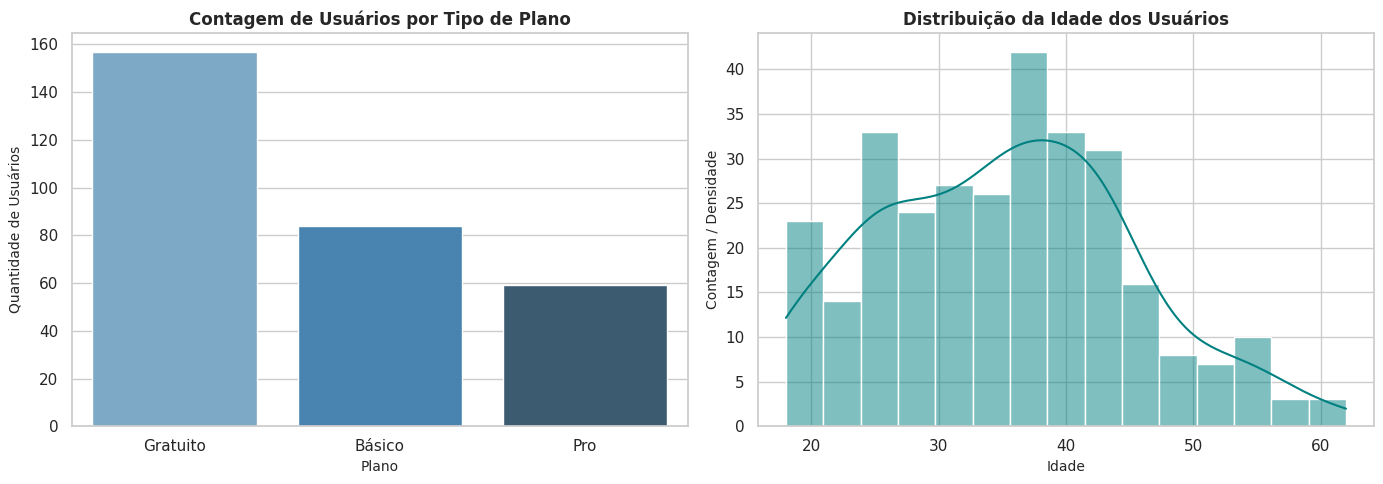

In [2]:
plt.figure(figsize=(14, 5))

# 1. Gráfico de barras ordenado por frequência (countplot)
plt.subplot(1, 2, 1)
sns.countplot(
    data=df_sistema,
    x='plano',
    order=df_sistema['plano'].value_counts().index,
    palette='Blues_d'
)
plt.title('Contagem de Usuários por Tipo de Plano', fontsize=12, fontweight='bold')
plt.xlabel('Plano', fontsize=10)
plt.ylabel('Quantidade de Usuários', fontsize=10)

# 2. Histograma com curva de densidade (KDE) para a idade
plt.subplot(1, 2, 2)
sns.histplot(
    data=df_sistema,
    x='idade',
    kde=True,
    color='teal',
    bins=15
)
plt.title('Distribuição da Idade dos Usuários', fontsize=12, fontweight='bold')
plt.xlabel('Idade', fontsize=10)
plt.ylabel('Contagem / Densidade', fontsize=10)

plt.tight_layout()
plt.show()

/tmp/ipykernel_9412/152628290.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_9412/152628290.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


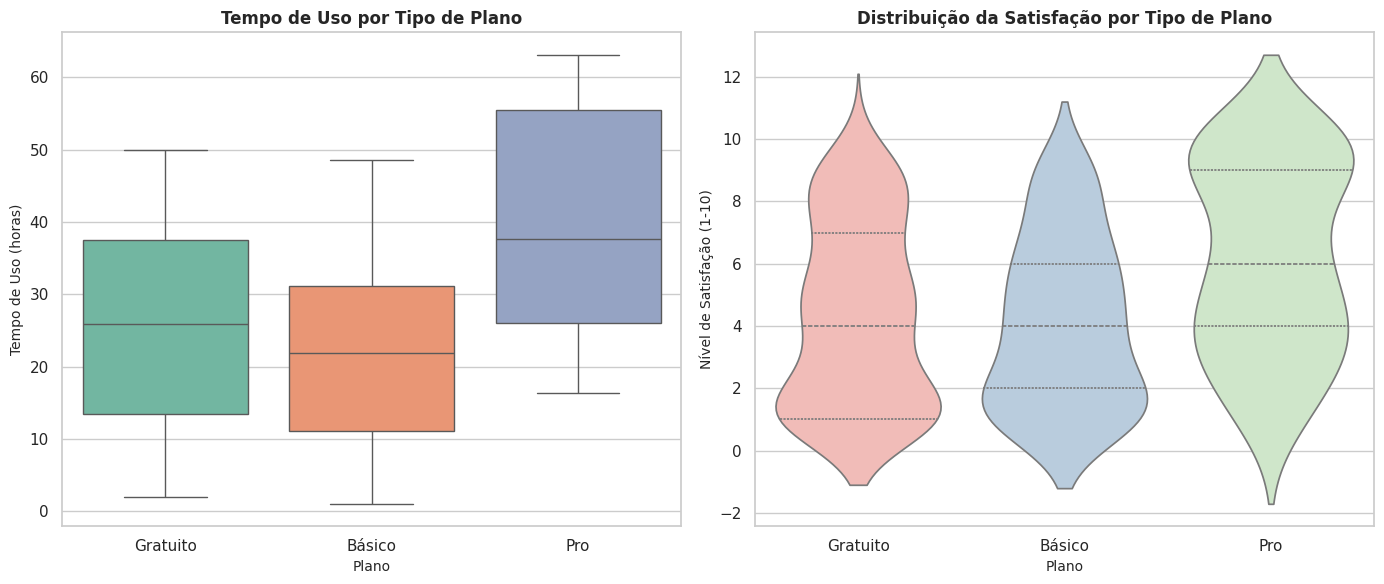

In [3]:
plt.figure(figsize=(14, 6))

# 3. Boxplot: Tempo de uso por tipo de plano
plt.subplot(1, 2, 1)
sns.boxplot(
    data=df_sistema,
    x='plano',
    y='tempo_uso_horas',
    palette='Set2'
)
plt.title('Tempo de Uso por Tipo de Plano', fontsize=12, fontweight='bold')
plt.xlabel('Plano', fontsize=10)
plt.ylabel('Tempo de Uso (horas)', fontsize=10)

# 4. Violinplot: Cruzamento de plano com satisfação
plt.subplot(1, 2, 2)
sns.violinplot(
    data=df_sistema,
    x='plano',
    y='satisfacao',
    palette='Pastel1',
    inner='quartile'
)
plt.title('Distribuição da Satisfação por Tipo de Plano', fontsize=12, fontweight='bold')
plt.xlabel('Plano', fontsize=10)
plt.ylabel('Nível de Satisfação (1-10)', fontsize=10)

plt.tight_layout()
plt.show()

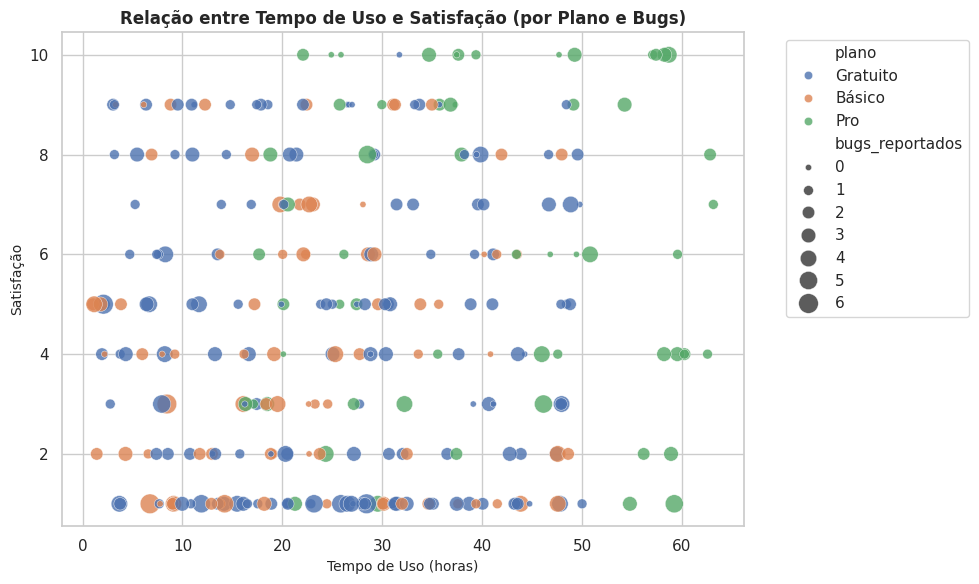

In [4]:
# 5. Scatterplot multivariado (Tempo de uso x Satisfação com hue e size)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_sistema,
    x='tempo_uso_horas',
    y='satisfacao',
    hue='plano',
    size='bugs_reportados',
    sizes=(20, 200),
    palette='deep',
    alpha=0.8
)
plt.title('Relação entre Tempo de Uso e Satisfação (por Plano e Bugs)', fontsize=12, fontweight='bold')
plt.xlabel('Tempo de Uso (horas)', fontsize=10)
plt.ylabel('Satisfação', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

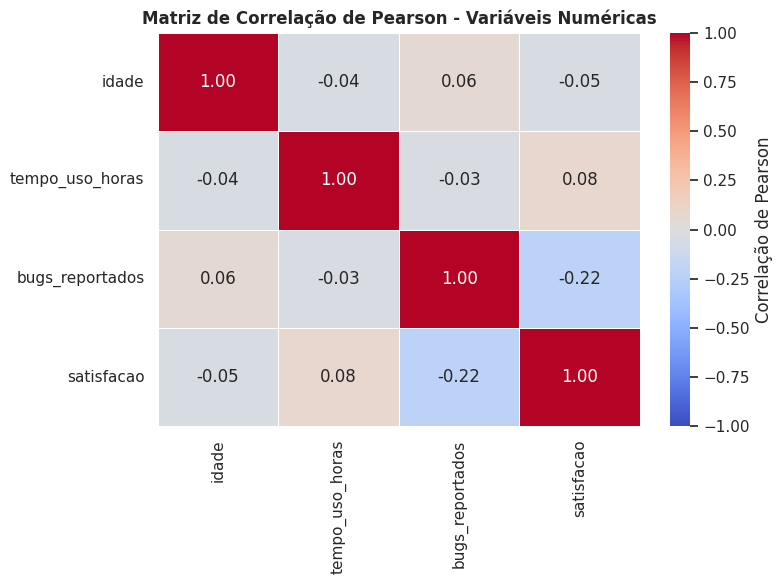

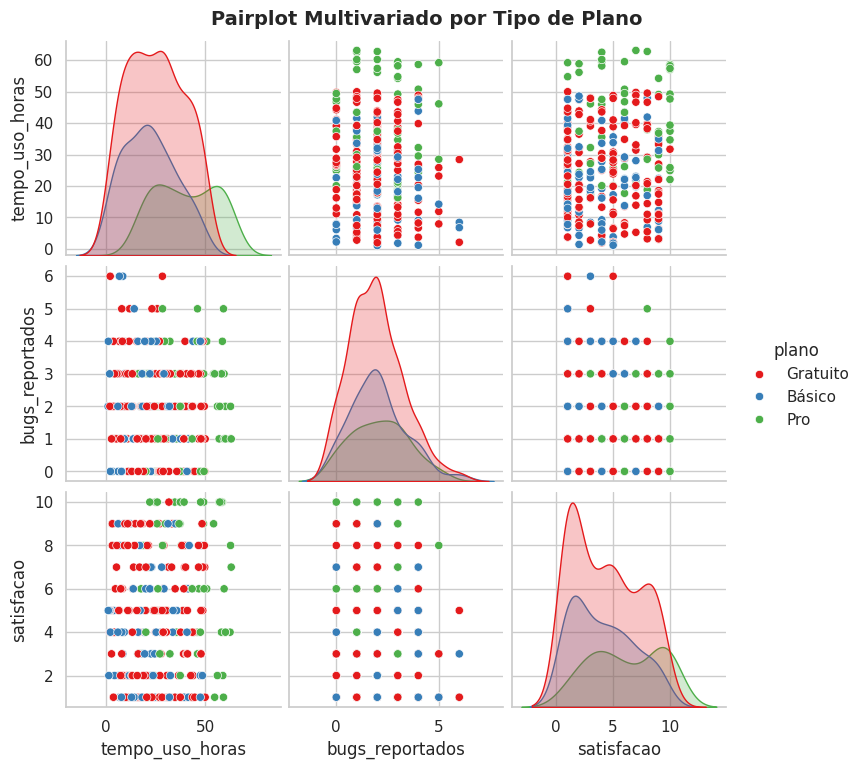

In [5]:
# 6. Matriz de correlação de Pearson (apenas variáveis numéricas)
plt.figure(figsize=(8, 6))
cols_numericas = df_sistema.select_dtypes(include=[np.number]).columns
matriz_corr = df_sistema[cols_numericas].corr()

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Correlação de Pearson'}
)
plt.title('Matriz de Correlação de Pearson - Variáveis Numéricas', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 7. (Bônus) Pairplot englobando tempo_uso_horas, bugs_reportados e satisfacao
pairplot_fig = sns.pairplot(
    df_sistema,
    vars=['tempo_uso_horas', 'bugs_reportados', 'satisfacao'],
    hue='plano',
    palette='Set1',
    diag_kind='kde'
)
pairplot_fig.fig.suptitle('Pairplot Multivariado por Tipo de Plano', y=1.02, fontsize=14, fontweight='bold')
plt.show()


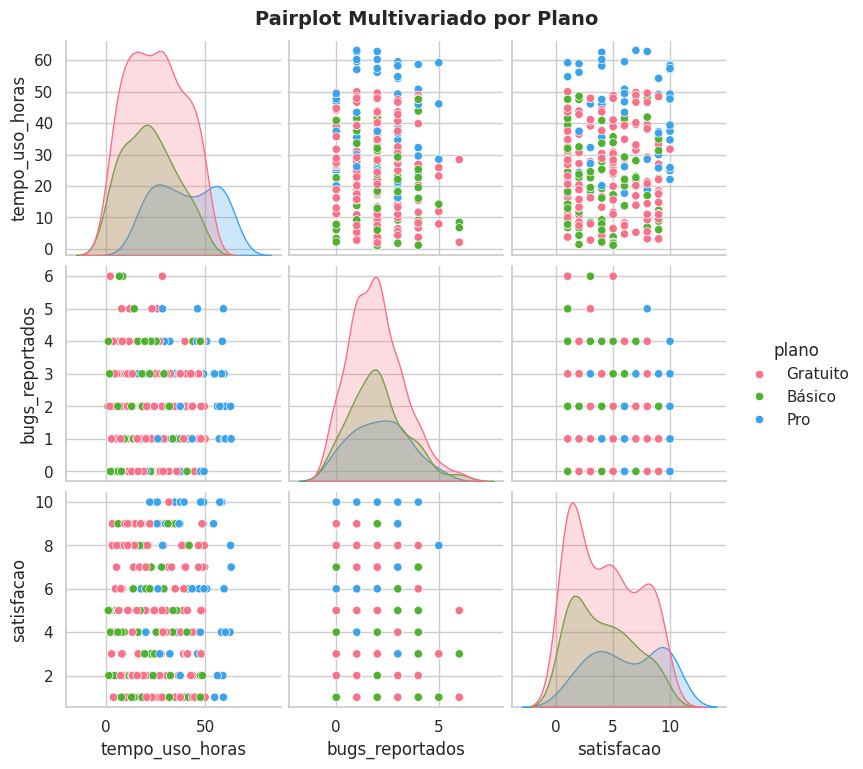

In [6]:
sns.pairplot(
    df_sistema[['tempo_uso_horas', 'bugs_reportados', 'satisfacao', 'plano']],
    hue='plano',
    palette='husl',
    diag_kind='kde'
)
plt.suptitle('Pairplot Multivariado por Plano', y=1.02, fontsize=14, weight='bold')
plt.show()